# Week 2 - Aido Rover Telemetry Exploratory Data Analysis

This notebook applies an exploratory data analysis pipeline to the synthetic Aido Rover telemetry dataset.

The analysis follows the NTU atmospheric science data analysis standard:
- Full-range profiling of each variable
- Distribution and outlier analysis
- Missingness assessment
- Cross-variable correlation analysis
- Stationarity testing
- Temporal aggregation
- Spatial distribution analysis

## Step 1 - Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

## Step 2 - Load the Telemetry Dataset

In [3]:
telemetry = pd.read_csv(
    "aido_rover_telemetry.csv",
    parse_dates=["timestamp"]
)

print("Dataset shape:", telemetry.shape)
telemetry.head()

Dataset shape: (181440, 20)


,rover_id,timestamp,operational_mode,latitude,longitude,lidar_distance_m,wheel_torque_fl,wheel_torque_fr,wheel_torque_rl,wheel_torque_rr,imu_accel_x,imu_accel_y,imu_accel_z,ambient_temperature_c,battery_soc,task_success,gps_dropout_flag,lidar_saturation_flag,battery_drop_flag,sensor_noise_flag
0,AIDO_001,2026-07-01 00:00:00,PATROL,1.354202,103.821034,13.699527,15.488216,17.496137,18.483317,16.461332,0.027548,0.065830,9.635538,22.987241,76.428284,1,0,0,0,0
1,AIDO_001,2026-07-01 00:05:00,FAULT,1.354486,103.820582,0.486087,5.560991,19.340842,4.025754,12.218663,-0.209815,-0.043348,9.601425,21.239938,76.275079,1,0,0,0,0
2,AIDO_001,2026-07-01 00:10:00,ALERT,1.354647,103.820291,0.976473,35.108406,21.019085,15.790379,27.107367,-0.009860,-0.163633,9.721586,21.241867,76.155109,1,0,0,0,0
3,AIDO_001,2026-07-01 00:15:00,PATROL,1.353859,103.821427,6.150354,22.704654,16.397383,12.056365,20.362447,0.554334,-0.029707,9.735898,21.616087,76.014695,1,0,0,0,0
4,AIDO_001,2026-07-01 00:20:00,PATROL,1.354567,103.820920,12.263115,24.153797,10.759237,13.542237,20.654680,-0.063300,-0.234918,10.039323,21.213952,75.885342,1,0,0,0,0


## Step 3 - Inspect Dataset Structure and Data Quality

In [4]:
telemetry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181440 entries, 0 to 181439
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   rover_id               181440 non-null  object        
 1   timestamp              181440 non-null  datetime64[ns]
 2   operational_mode       181440 non-null  object        
 3   latitude               177812 non-null  float64       
 4   longitude              177812 non-null  float64       
 5   lidar_distance_m       181440 non-null  float64       
 6   wheel_torque_fl        181440 non-null  float64       
 7   wheel_torque_fr        181440 non-null  float64       
 8   wheel_torque_rl        181440 non-null  float64       
 9   wheel_torque_rr        181440 non-null  float64       
 10  imu_accel_x            181440 non-null  float64       
 11  imu_accel_y            181440 non-null  float64       
 12  imu_accel_z            181440 non-null  floa

In [5]:
telemetry.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
rover_id,181440,30,AIDO_001,6048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,181440,NaN,NaN,NaN,2026-07-11 11:57:30,2026-07-01 00:00:00,2026-07-06 05:58:45,2026-07-11 11:57:30,2026-07-16 17:56:15,2026-07-21 23:55:00,NaN
operational_mode,181440,4,PATROL,126960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,177812.0,NaN,NaN,NaN,1.352615,1.348149,1.351244,1.353029,1.354047,1.356129,0.001808
longitude,177812.0,NaN,NaN,NaN,103.819992,103.815875,103.818118,103.820153,103.821701,103.823806,0.001865
lidar_distance_m,181440.0,NaN,NaN,NaN,6.918539,0.100301,2.433849,5.490618,10.469235,50.0,6.239136
wheel_torque_fl,181440.0,NaN,NaN,NaN,18.627699,0.0,13.278764,17.722216,21.590809,115.538749,14.763934
wheel_torque_fr,181440.0,NaN,NaN,NaN,18.611777,0.0,13.212358,17.676944,21.53341,117.756817,14.805919
wheel_torque_rl,181440.0,NaN,NaN,NaN,18.612249,0.0,13.229451,17.697842,21.592822,119.997067,14.773453
wheel_torque_rr,181440.0,NaN,NaN,NaN,18.605393,0.0,13.235144,17.674719,21.554825,119.804684,14.78068


In [6]:
telemetry["operational_mode"].value_counts()

operational_mode
PATROL      126960
CHARGING     27351
ALERT        18163
FAULT         8966
Name: count, dtype: int64

## Step 4 - Define Continuous Telemetry Variables

In [7]:
continuous_columns = [
    "latitude",
    "longitude",
    "lidar_distance_m",
    "battery_soc",
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr",
    "imu_accel_x",
    "imu_accel_y",
    "imu_accel_z",
    "ambient_temperature_c"
]

telemetry[continuous_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,177812.0,1.352615,0.001808,1.348149,1.351244,1.353029,1.354047,1.356129
longitude,177812.0,103.819992,0.001865,103.815875,103.818118,103.820153,103.821701,103.823806
lidar_distance_m,181440.0,6.918539,6.239136,0.100301,2.433849,5.490618,10.469235,50.000000
battery_soc,181440.0,16.448470,26.023565,0.000000,0.048767,0.767734,27.961668,99.763088
wheel_torque_fl,181440.0,18.627699,14.763934,0.000000,13.278764,17.722216,21.590809,115.538749
wheel_torque_fr,181440.0,18.611777,14.805919,0.000000,13.212358,17.676944,21.533410,117.756817
wheel_torque_rl,181440.0,18.612249,14.773453,0.000000,13.229451,17.697842,21.592822,119.997067
wheel_torque_rr,181440.0,18.605393,14.780680,0.000000,13.235144,17.674719,21.554825,119.804684
imu_accel_x,181440.0,0.001441,1.809371,-34.791972,-0.213768,0.000904,0.216237,36.396733
imu_accel_y,181440.0,0.005194,1.800453,-33.413347,-0.213945,0.000314,0.212648,30.657786


## Plot 1 - Battery SoC Distribution by Operational Mode

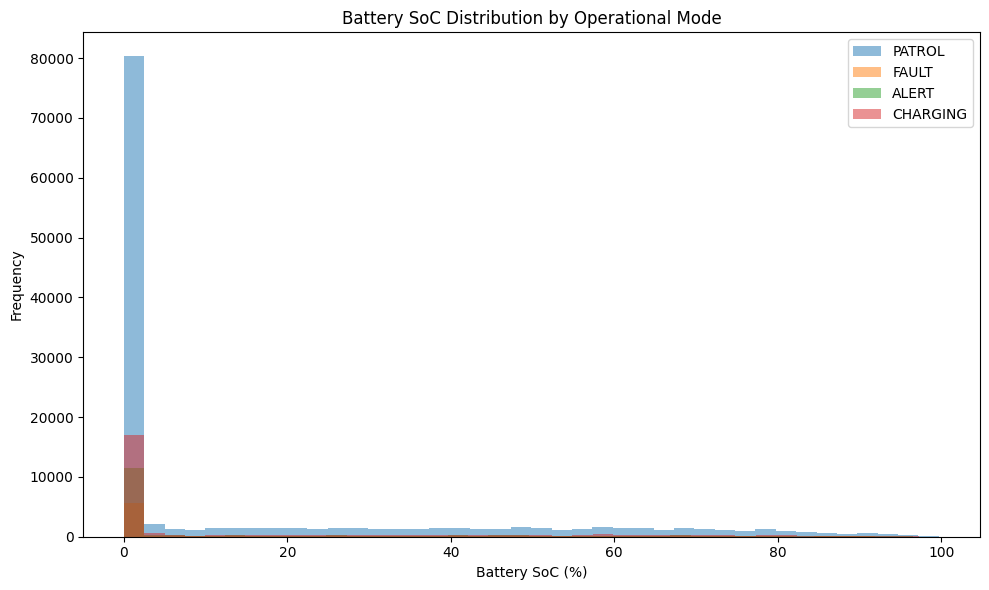

In [8]:
plt.figure(figsize=(10, 6))

for mode in telemetry["operational_mode"].unique():
    subset = telemetry.loc[
        telemetry["operational_mode"] == mode,
        "battery_soc"
    ]

    plt.hist(
        subset,
        bins=40,
        alpha=0.5,
        label=mode
    )

plt.xlabel("Battery SoC (%)")
plt.ylabel("Frequency")
plt.title("Battery SoC Distribution by Operational Mode")
plt.legend()
plt.tight_layout()
plt.show()

**Figure 1. Battery SoC distribution by operational mode**  
Battery SoC is heavily concentrated near 0% across all operational modes, indicating that the simulated rovers spend a large proportion of the observation period at very low battery levels. The CHARGING mode does not produce a clearly higher SoC distribution, suggesting that the synthetic charging logic is insufficient to restore battery levels consistently.

## Plot 2 - Battery SoC Outliers by Operational Mode

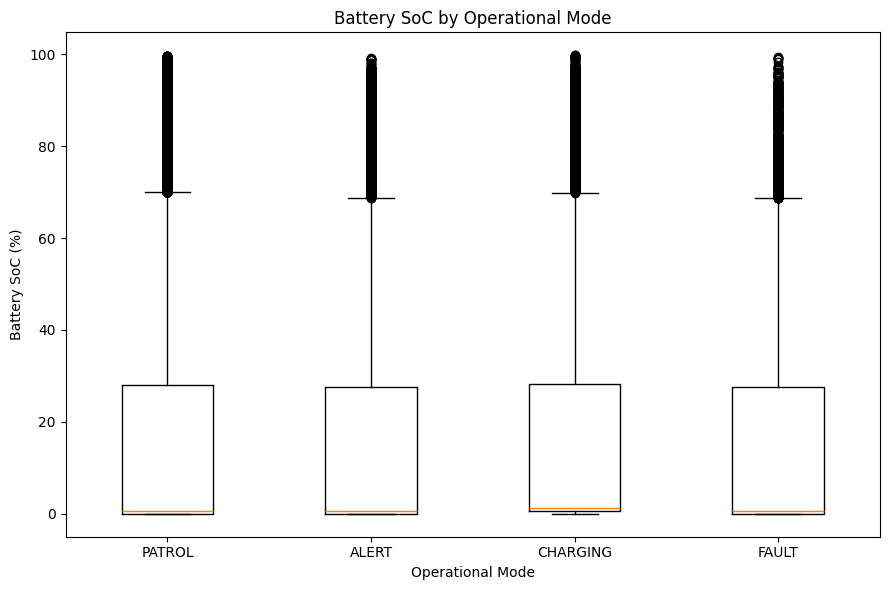

In [9]:
modes = ["PATROL", "ALERT", "CHARGING", "FAULT"]

battery_groups = [
    telemetry.loc[
        telemetry["operational_mode"] == mode,
        "battery_soc"
    ].dropna()
    for mode in modes
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    battery_groups,
    tick_labels=modes
)

plt.xlabel("Operational Mode")
plt.ylabel("Battery SoC (%)")
plt.title("Battery SoC by Operational Mode")
plt.tight_layout()
plt.show()

**Figure 2. Battery SoC box plots across operational modes**  
Battery SoC is strongly concentrated at low levels across all four operational modes, with median values close to 0% and similar interquartile ranges. CHARGING shows only a slightly higher median than the other modes, indicating that the simulated charging behavior does not substantially separate its battery distribution from active or fault states. Values above approximately 70% appear as statistical outliers because high battery levels are relatively uncommon in the dataset.

## Plot 3 - LiDAR Distance Distribution by Operational Mode

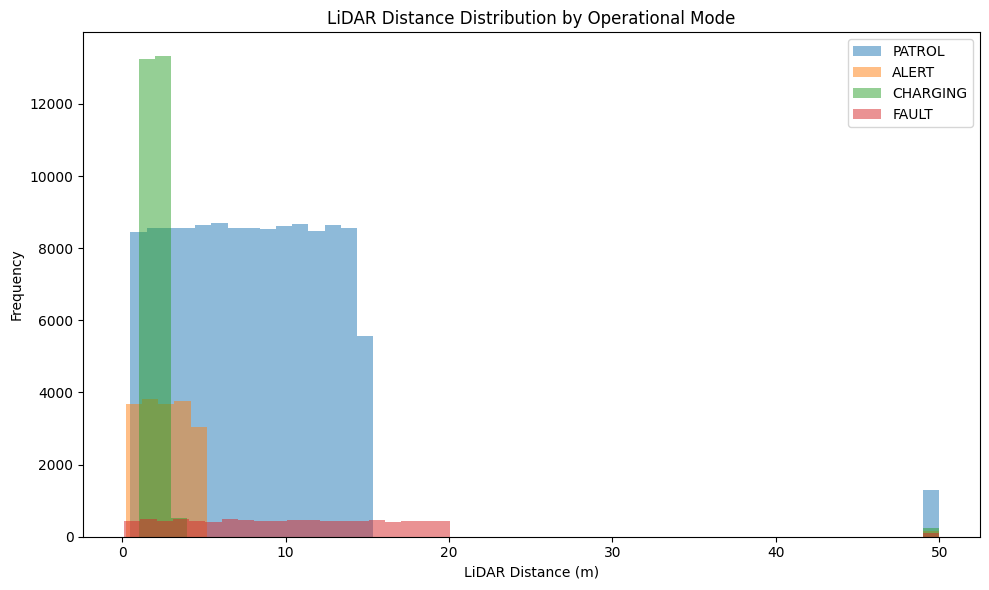

In [10]:
plt.figure(figsize=(10, 6))

for mode in modes:
    subset = telemetry.loc[
        telemetry["operational_mode"] == mode,
        "lidar_distance_m"
    ]

    plt.hist(
        subset,
        bins=50,
        alpha=0.5,
        label=mode
    )

plt.xlabel("LiDAR Distance (m)")
plt.ylabel("Frequency")
plt.title("LiDAR Distance Distribution by Operational Mode")
plt.legend()
plt.tight_layout()
plt.show()

**Figure 3. LiDAR distance distribution by operational mode**  
LiDAR readings show distinct distributions across operational modes. PATROL covers a broad range of approximately 0.5–15 m, ALERT is concentrated below approximately 5 m, and CHARGING shows the narrowest range at approximately 1–3 m. FAULT observations span a wider range up to approximately 20 m. A separate spike at exactly 50 m represents the intentionally injected 1% LiDAR saturation events and provides a clear example of sensor anomalies detectable through distribution analysis.

## Plot 4 - Wheel Torque Distribution and Outliers

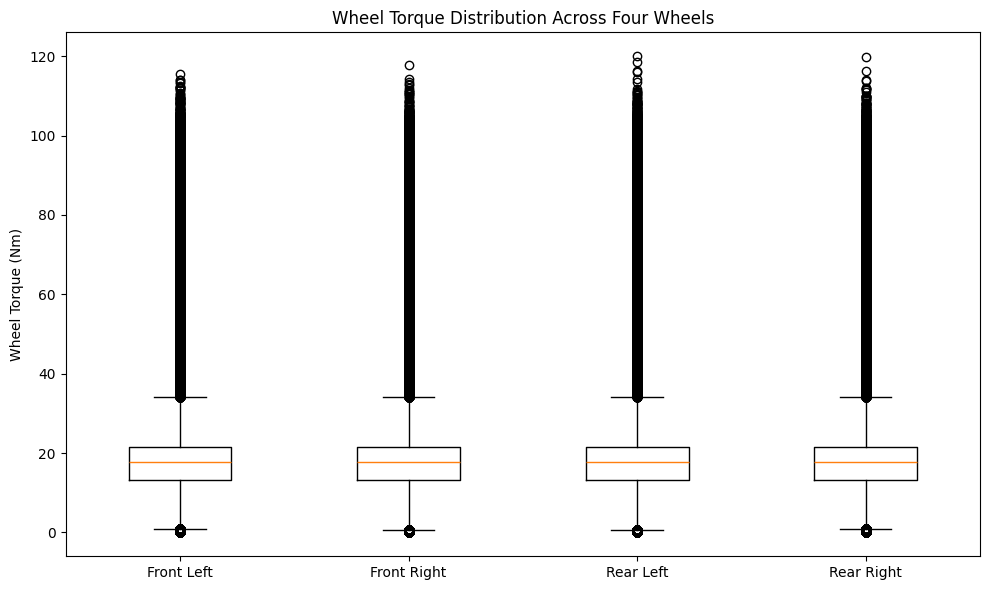

In [11]:
torque_columns = [
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr"
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    [telemetry[col].dropna() for col in torque_columns],
    tick_labels=["Front Left", "Front Right", "Rear Left", "Rear Right"]
)

plt.ylabel("Wheel Torque (Nm)")
plt.title("Wheel Torque Distribution Across Four Wheels")
plt.tight_layout()
plt.show()

**Figure 4. Wheel torque distributions across the four wheels**  
All four wheel torque channels show very similar distributions, with median values around 18 Nm and comparable interquartile ranges, indicating strong cross-wheel consistency. Numerous high-value statistical outliers extend to approximately 120 Nm, many of which are associated with the injected sensor noise spikes. Low-torque observations near 0 Nm may reflect normal low-motion states such as CHARGING and should not automatically be interpreted as anomalies.

## Step 5 - Missingness Analysis

Missing observations are quantified for each field to determine whether dropout is isolated or associated with other telemetry characteristics.

In [12]:
missing_summary = pd.DataFrame({
    "missing_count": telemetry.isna().sum(),
    "missing_percent": telemetry.isna().mean() * 100
})

missing_summary[
    missing_summary["missing_count"] > 0
]

,missing_count,missing_percent
latitude,3628,1.999559
longitude,3628,1.999559


## Plot 5 - Missing Values by Field

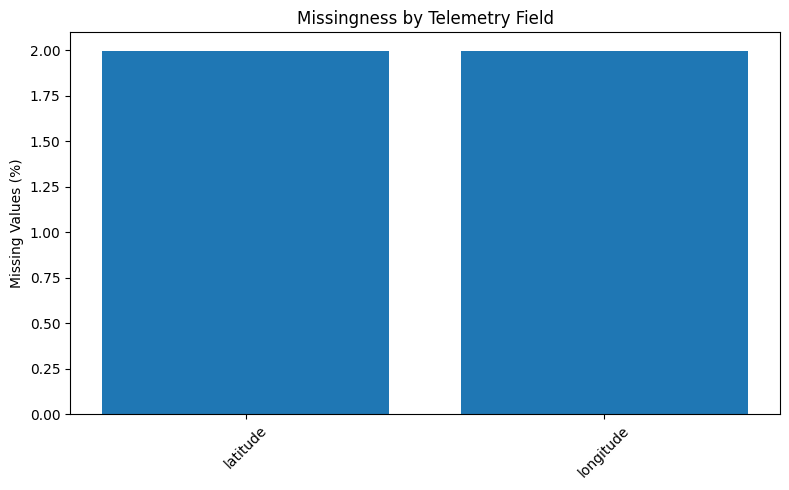

In [13]:
missing_percent = telemetry.isna().mean() * 100
missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(8, 5))

plt.bar(
    missing_percent.index,
    missing_percent.values
)

plt.ylabel("Missing Values (%)")
plt.title("Missingness by Telemetry Field")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Figure 5. Percentage of missing values by telemetry field**  
Missingness is limited to the GPS latitude and longitude channels, with approximately 2% of observations missing in each field. This matches the intentionally injected GPS dropout rate. Because the dropout observations were randomly selected independently of rover, time, operational mode, and other sensor measurements, the synthetic missingness mechanism is classified as MCAR.

### Missingness Mechanism

The GPS dropout is classified as **Missing Completely At Random (MCAR)** because the missing observations were randomly injected without conditioning on rover identity, operational mode, time, or other sensor measurements.

In a real telemetry dataset, the missingness mechanism would require further investigation because dropout could be associated with operational conditions such as battery level, rover state, location, or sensor failure.

Compared with atmospheric datasets, the same principle applies: missing observations should be evaluated to determine whether dropout is random or associated with observed conditions.

## Plot 6 - Cross-Channel Correlation Heatmap

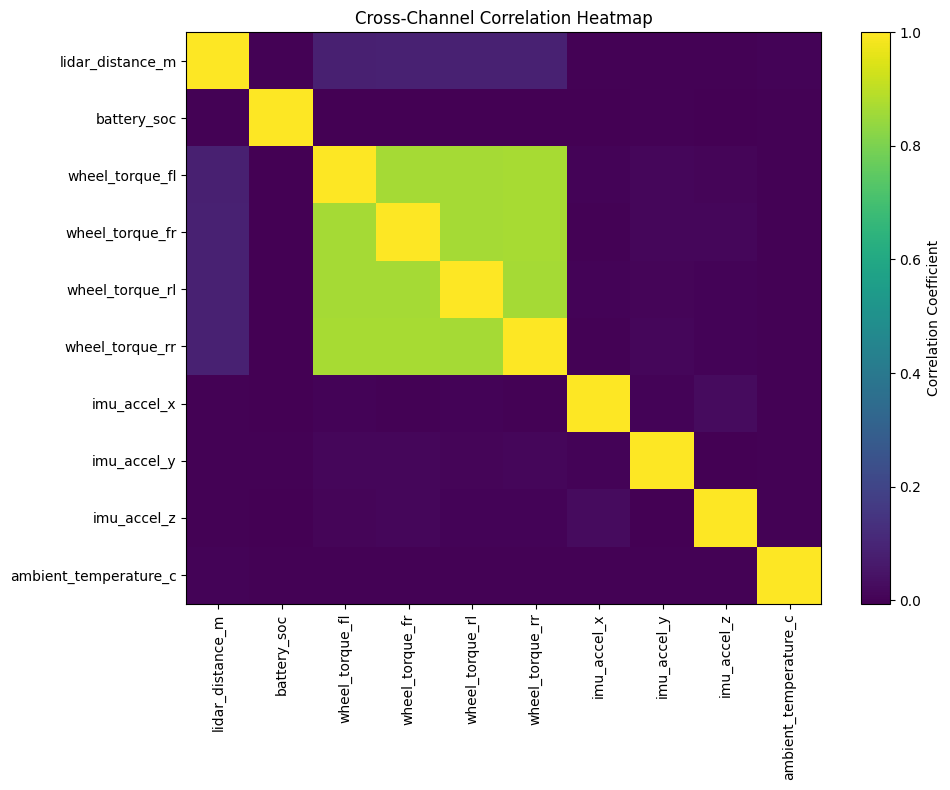

In [14]:
correlation_columns = [
    "lidar_distance_m",
    "battery_soc",
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr",
    "imu_accel_x",
    "imu_accel_y",
    "imu_accel_z",
    "ambient_temperature_c"
]

corr_matrix = telemetry[correlation_columns].corr()

plt.figure(figsize=(10, 8))

plt.imshow(
    corr_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation Coefficient")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title("Cross-Channel Correlation Heatmap")
plt.tight_layout()
plt.show()

**Figure 6. Cross-channel correlation heatmap for continuous telemetry sensors**  
The four wheel torque channels show the strongest positive correlations, with pairwise correlation coefficients ranging from approximately 0.865 to 0.867, indicating strong cross-wheel consistency. LiDAR distance has only a weak positive relationship with wheel torque (r ≈ 0.085), while battery SoC, IMU acceleration, and ambient temperature show little linear correlation with most other channels. The weak battery–torque relationship is notable because stronger physical coupling between mechanical load and energy consumption might be expected in real rover telemetry.

### Strongest Cross-Channel Correlations

Extract the unique correlation pairs to identify the strongest relationships observed in the heatmap.

In [15]:
# Extract unique correlation pairs
corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

print("Top 10 Cross-Channel Correlations:")
print(corr_pairs.head(10))

Top 10 Cross-Channel Correlations:
wheel_torque_fl   wheel_torque_rr    0.866970
wheel_torque_fr   wheel_torque_rr    0.866721
wheel_torque_fl   wheel_torque_fr    0.865540
                  wheel_torque_rl    0.865010
wheel_torque_fr   wheel_torque_rl    0.864955
wheel_torque_rl   wheel_torque_rr    0.864695
lidar_distance_m  wheel_torque_rl    0.085718
                  wheel_torque_fr    0.085657
                  wheel_torque_rr    0.084590
                  wheel_torque_fl    0.084462
dtype: float64


### Correlation Interpretation

The four wheel torque channels show the strongest relationships in the dataset, with pairwise correlation coefficients ranging from approximately **0.865 to 0.867**. This is expected because all four wheels respond to the same operational mode and therefore tend to increase or decrease together.

LiDAR distance shows only a weak positive correlation with wheel torque (**r ≈ 0.085**), while battery SoC, IMU acceleration, and ambient temperature show little linear correlation with most other sensor channels.

One notable result is the weak relationship between battery SoC and wheel torque. In real rover operation, sustained mechanical load may be expected to affect energy consumption. The weak relationship in this dataset reflects a limitation of the synthetic generation process, where the sensor channels were not modeled with strong direct physical dependencies.

## Step 6 - Stationarity Testing

The Augmented Dickey-Fuller test is applied to battery SoC and wheel torque for a representative rover.

Null hypothesis: the time series contains a unit root and is non-stationary.

A p-value below 0.05 provides evidence to reject the null hypothesis.

In [16]:
rover_ts = (
    telemetry[
        telemetry["rover_id"] == "AIDO_003"
    ]
    .sort_values("timestamp")
    .copy()
)

In [17]:
battery_adf = adfuller(
    rover_ts["battery_soc"].dropna()
)

print("Battery SoC ADF Test")
print(f"ADF Statistic: {battery_adf[0]:.4f}")
print(f"p-value: {battery_adf[1]:.4f}")

Battery SoC ADF Test
ADF Statistic: -8.7546
p-value: 0.0000


In [18]:
torque_adf = adfuller(
    rover_ts["wheel_torque_fl"].dropna()
)

print("Front-left Wheel Torque ADF Test")
print(f"ADF Statistic: {torque_adf[0]:.4f}")
print(f"p-value: {torque_adf[1]:.4f}")

Front-left Wheel Torque ADF Test
ADF Statistic: -79.6041
p-value: 0.0000


### Stationarity Test Results

The Augmented Dickey-Fuller (ADF) test was applied to the battery SoC and front-left wheel torque time series for AIDO_003.

| Variable | ADF Statistic | p-value | Result |
|---|---:|---:|---|
| Battery SoC | -8.7546 | < 0.001 | Stationary |
| Front-left Wheel Torque | -79.6041 | < 0.001 | Stationary |

For both variables, the p-value is below the 0.05 significance level. Therefore, the null hypothesis of a unit root is rejected for both time series.

The ADF test provides statistical evidence of stationarity for both series. However, the battery SoC time series shows a strong decline toward its lower boundary and remains near 0% for much of the observation period. This demonstrates that statistical stationarity does not necessarily indicate healthy or realistic operational behavior.

The wheel torque series shows stronger evidence of stationarity, with values fluctuating around relatively stable operating levels despite occasional sensor noise spikes.

## Plot 7 - Operational Mode Distribution by Hour of Day

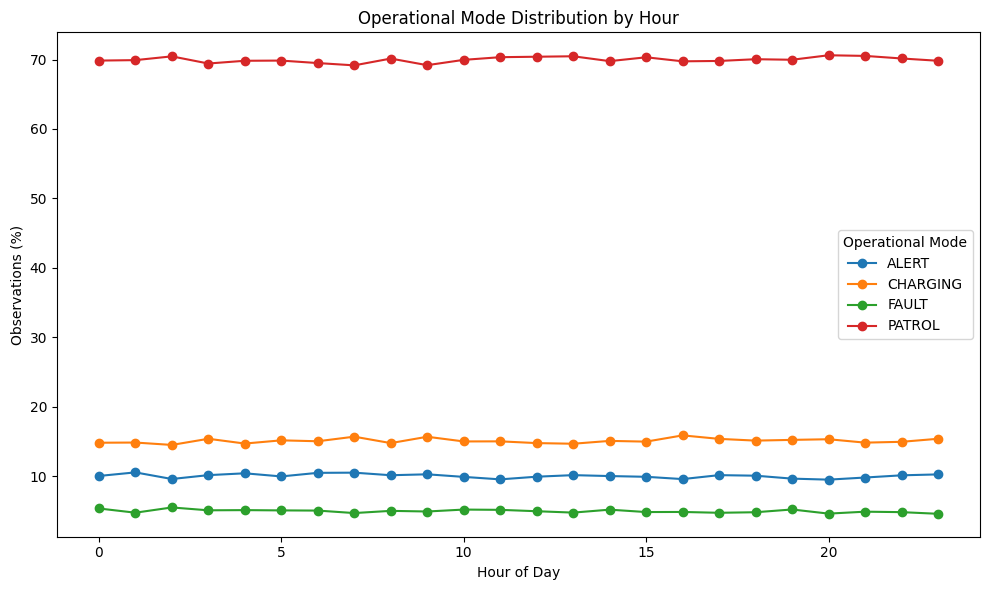

In [19]:
telemetry["hour"] = telemetry["timestamp"].dt.hour

hourly_mode = (
    telemetry
    .groupby(["hour", "operational_mode"])
    .size()
    .unstack(fill_value=0)
)

hourly_mode_percent = hourly_mode.div(
    hourly_mode.sum(axis=1),
    axis=0
) * 100

hourly_mode_percent.plot(
    kind="line",
    figsize=(10, 6),
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Observations (%)")
plt.title("Operational Mode Distribution by Hour")
plt.legend(title="Operational Mode")
plt.tight_layout()
plt.show()

**Figure 7. Operational mode distribution by hour of day**  
Operational mode proportions remain nearly constant throughout the 24-hour cycle, with approximately 70% PATROL, 15% CHARGING, 10% ALERT, and 5% FAULT observations at each hour. The small fluctuations are consistent with random sampling variation rather than a clear hourly pattern. This reflects the synthetic generation process, in which operational mode probabilities were not dependent on time of day.

## Plot 8 - Daily Operational Mode Distribution

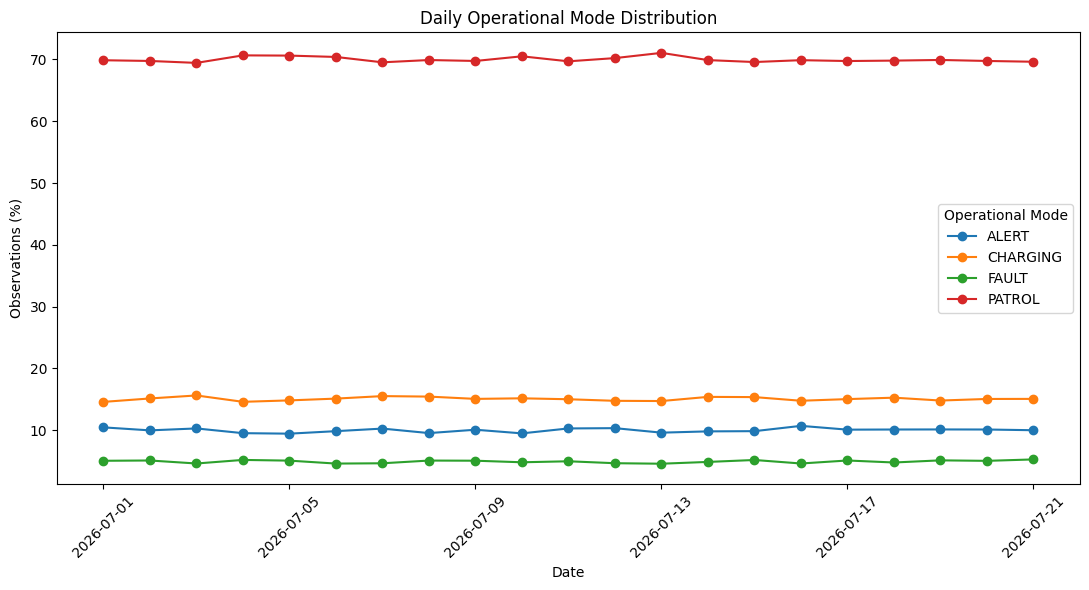

In [20]:
telemetry["date"] = telemetry["timestamp"].dt.date

daily_mode = (
    telemetry
    .groupby(["date", "operational_mode"])
    .size()
    .unstack(fill_value=0)
)

daily_mode_percent = daily_mode.div(
    daily_mode.sum(axis=1),
    axis=0
) * 100

daily_mode_percent.plot(
    figsize=(11, 6),
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Observations (%)")
plt.title("Daily Operational Mode Distribution")
plt.xticks(rotation=45)
plt.legend(title="Operational Mode")
plt.tight_layout()
plt.show()

**Figure 8. Daily operational mode distribution across the 21-day observation period**  
Operational mode proportions remain stable from day to day, with approximately 70% PATROL, 15% CHARGING, 10% ALERT, and 5% FAULT observations throughout the study period. The small daily fluctuations are consistent with random sampling variation, and no clear increasing or decreasing temporal trend is observed. This reflects the fixed operational mode probabilities used in the synthetic data generation process.

## Plot 9 - Spatial Distribution by Operational Mode

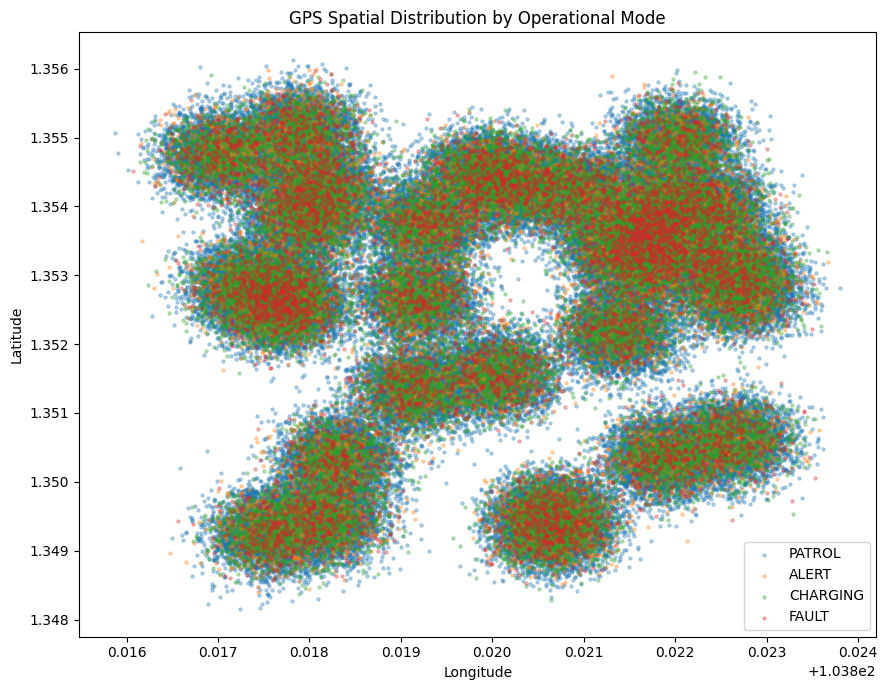

In [21]:
gps_data = telemetry.dropna(
    subset=["latitude", "longitude"]
)

plt.figure(figsize=(9, 7))

for mode in modes:
    subset = gps_data[
        gps_data["operational_mode"] == mode
    ]

    plt.scatter(
        subset["longitude"],
        subset["latitude"],
        s=5,
        alpha=0.3,
        label=mode
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GPS Spatial Distribution by Operational Mode")
plt.legend()
plt.tight_layout()
plt.show()

**Figure 9. GPS spatial distribution by operational mode**  
Rover observations form several distinct spatial clusters and movement regions across the simulated operating area. However, PATROL, ALERT, CHARGING, and FAULT observations largely overlap spatially, with no clear mode-specific region. This reflects the synthetic generation process, in which operational modes were not strongly dependent on GPS location. In a real rover fleet, stronger spatial patterns might be expected, such as CHARGING observations concentrated near docking stations or elevated FAULT rates in specific operating areas.

## Plot 10 - Spatial Distribution by Battery State of Charge

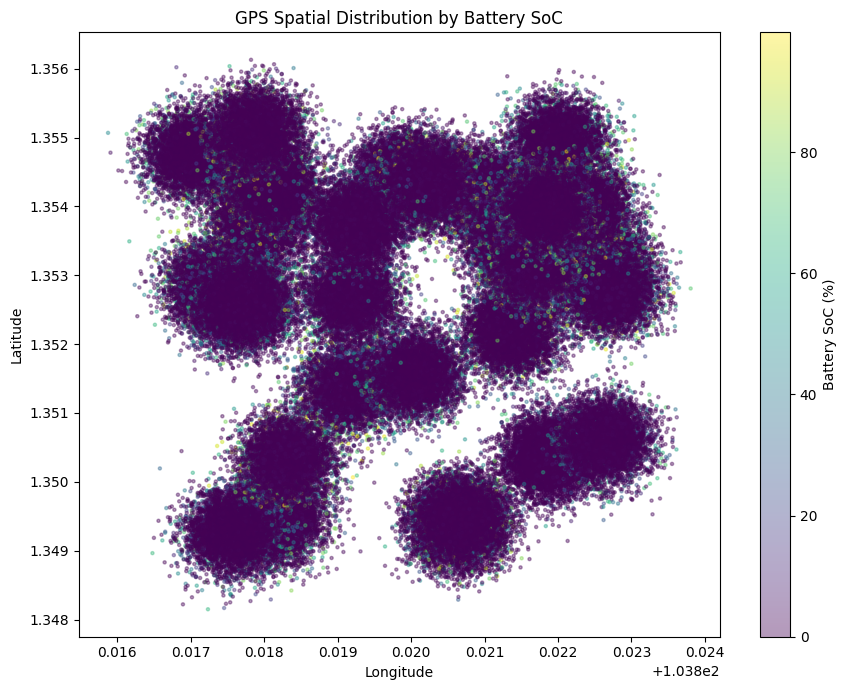

In [22]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    gps_data["longitude"],
    gps_data["latitude"],
    c=gps_data["battery_soc"],
    s=5,
    alpha=0.4
)

plt.colorbar(
    scatter,
    label="Battery SoC (%)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GPS Spatial Distribution by Battery SoC")
plt.tight_layout()
plt.show()

**Figure 10. GPS spatial distribution coloured by battery SoC**  
Most GPS observations are associated with very low battery SoC, shown by the dominance of dark-purple points across all spatial clusters. Higher battery levels occur occasionally throughout the operating area, but no clear spatial concentration or battery gradient is visually apparent. This is consistent with the synthetic data design, in which battery behavior was not directly dependent on GPS location.

## Plot 11 - Battery SoC and Wheel Torque Time Series for AIDO_003

Visualize the battery SoC and front-left wheel torque time series used in the stationarity analysis.

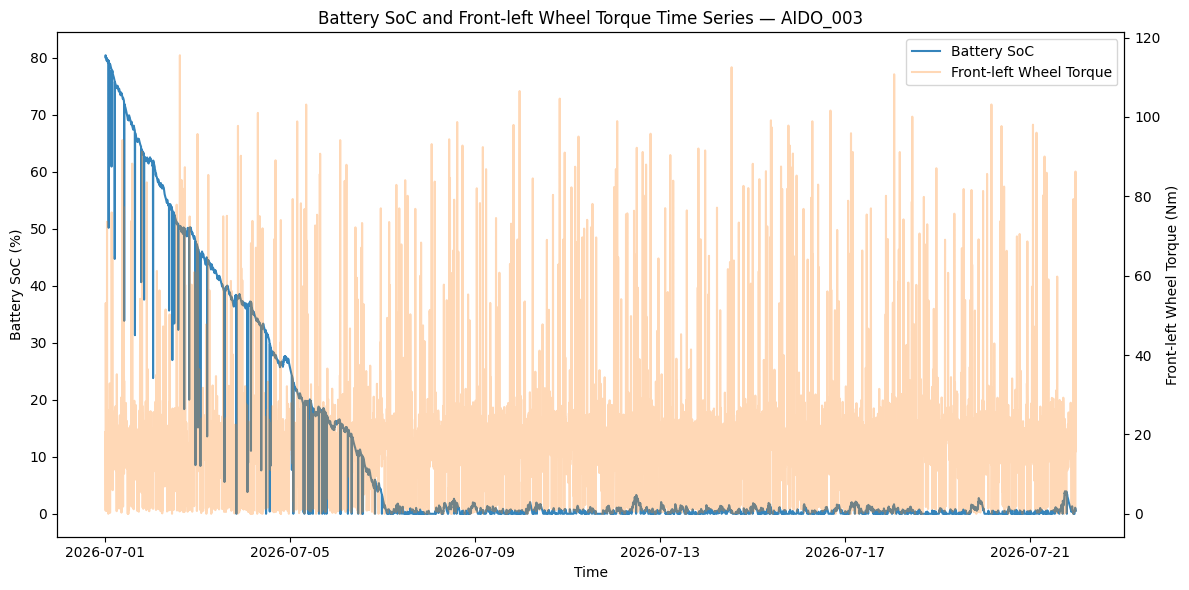

In [26]:
rover_plot = (
    telemetry[telemetry["rover_id"] == "AIDO_003"]
    .sort_values("timestamp")
)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Battery SoC
line1, = ax1.plot(
    rover_plot["timestamp"],
    rover_plot["battery_soc"],
    color="tab:blue",
    label="Battery SoC",
    alpha=0.9
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Battery SoC (%)")

# Wheel torque
ax2 = ax1.twinx()

line2, = ax2.plot(
    rover_plot["timestamp"],
    rover_plot["wheel_torque_fl"],
    color="tab:orange",
    label="Front-left Wheel Torque",
    alpha=0.3
)

ax2.set_ylabel("Front-left Wheel Torque (Nm)")

ax1.legend(
    [line1, line2],
    ["Battery SoC", "Front-left Wheel Torque"],
    loc="upper right"
)

plt.title(
    "Battery SoC and Front-left Wheel Torque Time Series — AIDO_003"
)

fig.tight_layout()
plt.show()

**Figure 11. Battery SoC and front-left wheel torque time series for AIDO_003**  
Battery SoC declines from approximately 80% at the beginning of the observation period to near 0% by approximately July 6 and remains at very low levels for most of the remaining period. This reflects a limitation of the synthetic generation logic, where charging is assigned independently of battery level rather than being triggered by low SoC. Front-left wheel torque continues to fluctuate around its typical operating range, with occasional extreme spikes associated with the injected sensor noise. Although the ADF tests reject the unit-root null hypothesis for both battery SoC (ADF = -8.7546, p < 0.001) and wheel torque (ADF = -79.6041, p < 0.001), the battery time series demonstrates that statistical stationarity should not be interpreted as healthy operational behavior.